In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import psutil
print(f"Available RAM: {psutil.virtual_memory().available / 1024**3:.1f} GB")


Available RAM: 3.8 GB


## Load OG df

In [ ]:
og_df = pd.read_pickle('/Volumes/OPERA3/Nathan/data/macrohet/macrohet_results/dfs/sc_df.pkl')

In [ ]:
og_df

In [5]:
df = pd.read_pickle('/Volumes/OPERA3/Nathan/data/macrohet/Z_stack_tests/results/3.3.max_proj_sc_df.update.pkl')

In [6]:
df

,t,ID,z,y,x,cell_area_px,mtb_area_px,segment_ID,row,col,Mtb Area (µm),Time (hours),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),r2,Doubling Amounts,Doubling Times,mtb_origin
0,0,1,24,866.0,6511.0,18900.0,0.0,817.0,3.0,3.0,0.000000,0.0,0.000000,0.0,0.000000,1.000000,"[1.92, 3.84, 7.68, 15.36]","[1.0, 0.5, 8.0]",Transfer
1,0,6,24,525.0,4880.0,17250.0,0.0,755.0,3.0,3.0,0.000000,0.0,0.000000,0.0,0.000000,0.804189,NaN,NaN,None
2,0,9,22,7490.0,1929.0,18000.0,0.0,64.0,3.0,3.0,0.000000,0.0,0.000000,0.0,0.144179,0.247361,NaN,NaN,None
3,0,10,22,4221.0,542.0,47050.0,101.0,1009.0,3.0,3.0,2.257073,0.0,2.257073,0.0,2.266954,0.916470,NaN,NaN,None
4,0,11,24,4548.0,823.0,23025.0,123.0,442.0,3.0,3.0,2.748713,0.0,2.748713,0.0,2.484378,0.810000,"[2.363652037311596, 4.727304074623192, 9.45460...","[5.0, 16.0, -1.0, -5.5]",Transfer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130363,96,8595,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,11.374755,48.0,11.374755,0.646219,NaN,NaN,None
130364,96,8597,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,3.195658,48.0,3.201369,0.584448,NaN,NaN,None
130365,96,8600,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.000000,48.0,0.000000,0.938153,"[1.92, 3.84, 7.68]","[-2.5, -16.0]",None
130366,96,8617,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.0,0.000000,48.0,0.000000,0.850124,"[1.92, 3.84]",[-5.5],None


# Plot all dt with ID colour code

/tmp/ipykernel_2149593/1894280801.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_2149593/1894280801.py:24: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


Text(0.5, 1.0, 'Doubling times over full 25µm max projection')

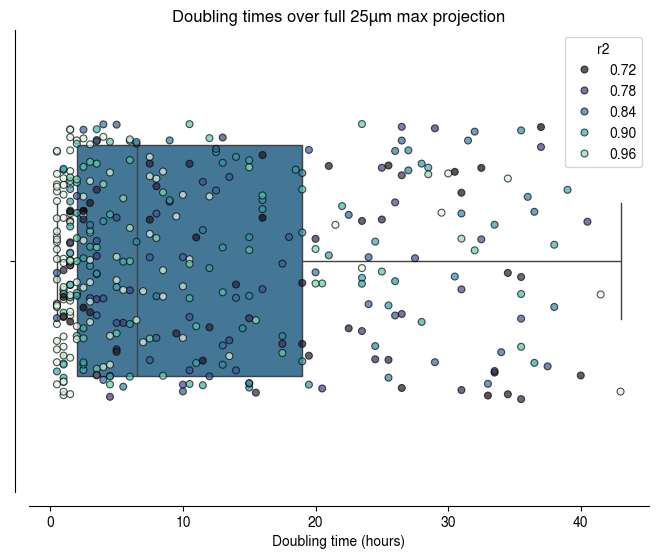

In [7]:
subset_df = (
    df.drop_duplicates(subset="ID")
      .dropna(subset=["Doubling Times"])
      .explode("Doubling Times")
)

subset_df = subset_df[
    # subset_df[id_key].isin(largest_IDs) &
    (subset_df["Doubling Times"] > 0) &
    (subset_df["r2"] >= 0.7)
].copy()

plt.figure(figsize=(8,6))
ax = sns.boxplot(
    data=subset_df,
    x="Doubling Times",
    whis=[0, 100],
    width=0.5,
    color=None,
    palette="mako"
)

# Overlay per-ID scatter, each ID with its own color + legend
sns.stripplot(
    data=subset_df,
    x="Doubling Times",
    hue="r2",              # categorical grouping
    palette="mako",           # or "tab10" for 10 distinct colors
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.3,
    dodge=False
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")

plt.title('Doubling times over full 25µm max projection')

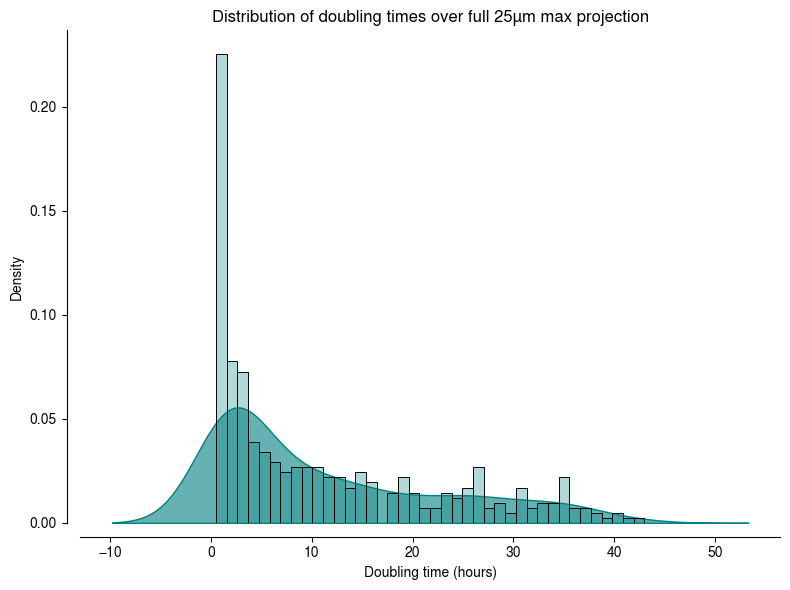

In [8]:
plt.figure(figsize=(8,6))

# Smooth KDE distribution
sns.kdeplot(
    data=subset_df,
    x="Doubling Times",
    fill=True,
    common_norm=False,
    alpha=0.6,
    color="teal"  # or use a palette if you want groups
)

# Optionally overlay a histogram
sns.histplot(
    data=subset_df,
    x="Doubling Times",
    bins=40,
    color="teal",
    alpha=0.3,
    stat="density"   # normalize so it overlays with KDE
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")
plt.title("Distribution of doubling times over full 25µm max projection")
plt.tight_layout()
plt.show()


In [9]:
subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
        & (og_df["mtb_origin"] == "Growth")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)

subset_og_df

,Time (hours),Mtb Area (µm),dMtb Area (µm),Mphi Area (µm),dMphi Area (µm),Infection Status,Initial Infection Status,Final Infection Status,x,y,...,dMtb Area between frames (µm),Mtb Area Processed (µm),Time Model (hours),Mtb Area Model (µm),mtb_origin,Doubling Amounts,Doubling Times,r2,Frame,category_rank
405,0.0,46.797680,136.772588,660.776979,-68.386294,NaN,1.0,1.0,519.922607,876.779602,...,NaN,NaN,NaN,NaN,Growth,"[50.6, 101.2]",28.0,0.97,0,NaN
8714,11.0,34.036708,140.325993,479.262769,952.290318,NaN,1.0,1.0,682.521484,528.266724,...,NaN,NaN,NaN,NaN,Growth,"[44.1, 88.2]",32.0,0.95,22,NaN
18973,0.0,9.810975,23.443537,769.569275,-185.492235,NaN,1.0,1.0,474.159943,709.874268,...,NaN,NaN,NaN,NaN,Growth,"[8.5, 17.0, 34.0]",29.0,0.91,0,NaN
18973,0.0,9.810975,23.443537,769.569275,-185.492235,NaN,1.0,1.0,474.159943,709.874268,...,NaN,NaN,NaN,NaN,Growth,"[8.5, 17.0, 34.0]",33.0,0.91,0,NaN
22011,0.0,51.736691,109.038147,500.292664,-184.799433,NaN,1.0,1.0,140.723206,642.738159,...,NaN,NaN,NaN,NaN,Growth,"[65.7, 131.4]",38.5,0.97,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1040123,3.0,6.145827,24.762096,1283.963844,-405.602238,NaN,1.0,1.0,465.167297,314.734009,...,NaN,NaN,NaN,NaN,Growth,"[6.9, 13.8, 27.6]",25.0,0.98,3,NaN
1040123,3.0,6.145827,24.762096,1283.963844,-405.602238,NaN,1.0,1.0,465.167297,314.734009,...,NaN,NaN,NaN,NaN,Growth,"[6.9, 13.8, 27.6]",33.0,0.98,3,NaN
1091757,4.0,2.346589,32.829891,1537.216616,-899.078630,NaN,1.0,1.0,1085.988037,704.828186,...,NaN,NaN,NaN,NaN,Growth,"[2.1, 4.2, 8.4, 16.8]",17.0,0.96,4,NaN
1091757,4.0,2.346589,32.829891,1537.216616,-899.078630,NaN,1.0,1.0,1085.988037,704.828186,...,NaN,NaN,NaN,NaN,Growth,"[2.1, 4.2, 8.4, 16.8]",15.0,0.96,4,NaN


/tmp/ipykernel_2149593/1962237016.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_2149593/1962237016.py:28: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_2149593/1962237016.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


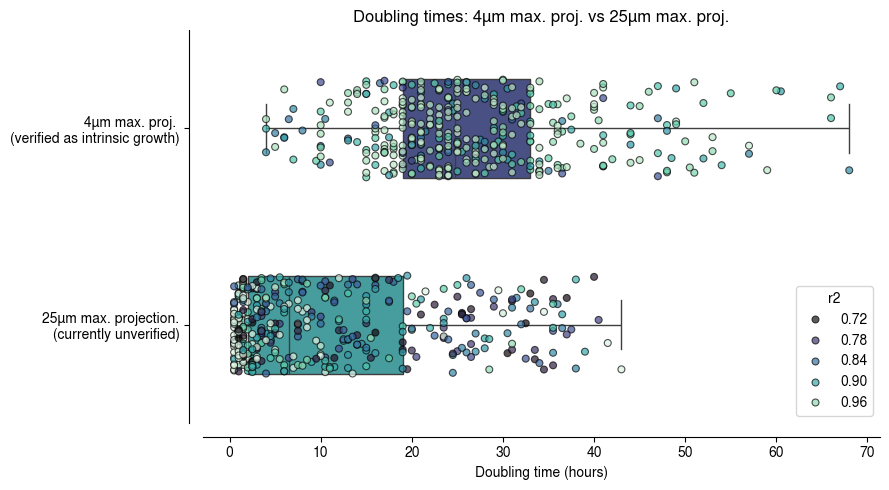

In [10]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    whis=[0, 100],
    width=0.5,
    fliersize=0,
    palette="mako",
    # hue='r2'
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    palette="mako",
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    hue='r2'
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel("")
ax.set_yticklabels([
    " 4µm max. proj. \n(verified as intrinsic growth)",
    "25µm max. projection.\n (currently unverified)"
])
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.")
# ax.legend(title="r²", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()


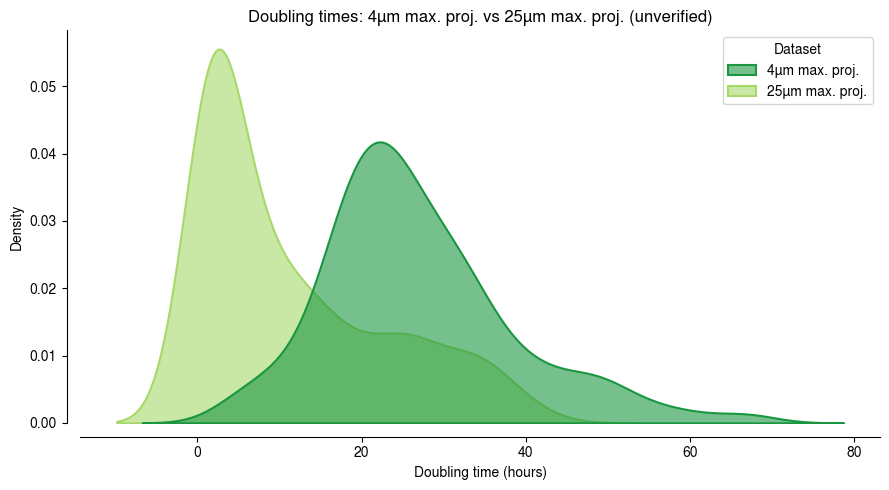

In [11]:
plt.figure(figsize=(9, 5))

# KDEs stacked along Y (ridge style)
sns.kdeplot(
    data=combo,
    x="Doubling Times",
    # y="Dataset",
    hue="Dataset",
    fill=True,
    common_norm=False,
    alpha=0.6,
    linewidth=1.5,
    palette=expanded_piyg[:2]  # two colors for the datasets
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")

plt.title("Doubling times: 4µm max. proj. vs 25µm max. proj. (unverified)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_2149593/3447116030.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_2149593/3447116030.py:30: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_2149593/3447116030.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


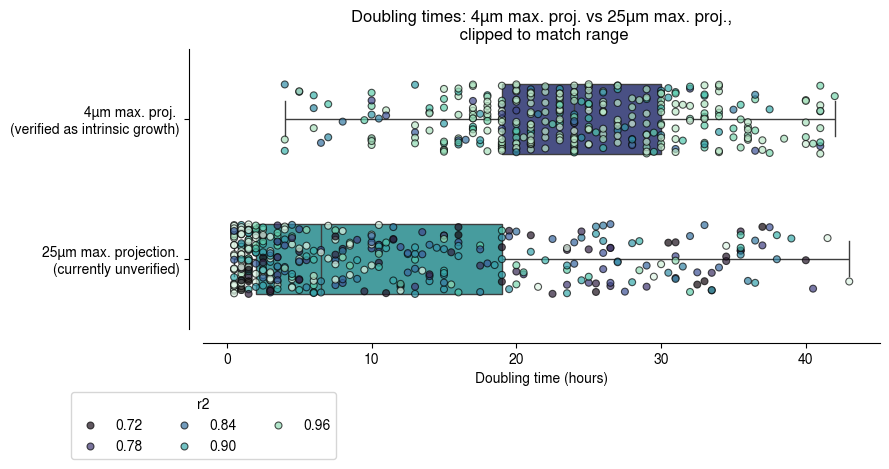

In [12]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

b = b[b['Doubling Times']<=a['Doubling Times'].max()]

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    whis=[0, 100],
    width=0.5,
    fliersize=0,
    palette="mako",
    # hue='r2'
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    palette="mako",
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    hue='r2'
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel('')
ax.set_yticklabels([
    " 4µm max. proj. \n(verified as intrinsic growth)",
    "25µm max. projection.\n (currently unverified)"
])
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.,\n clipped to match range")
ax.legend(
    bbox_to_anchor=(0., -0.2),
    loc="upper center",
    ncol=3,   # spread across columns
    frameon=True, 
    title='r2'
)
plt.tight_layout()


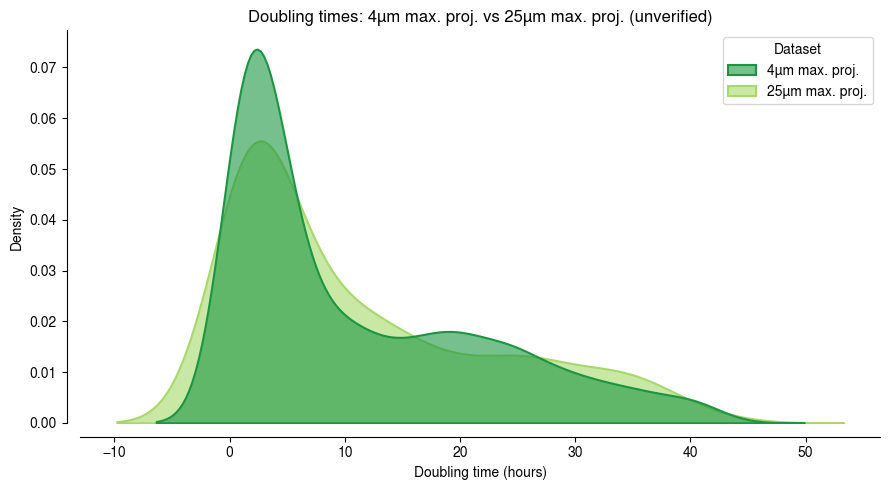

In [18]:
# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
a['mtb_origin'] = 'Unknown'


subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
        # & (og_df["mtb_origin"] == "Growth")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)


b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

b = b[b['Doubling Times']<=a['Doubling Times'].max()]

combo = pd.concat([a, b], ignore_index=True)

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

plt.figure(figsize=(9, 5))

# KDEs stacked along Y (ridge style)
sns.kdeplot(
    data=combo,
    x="Doubling Times",
    # y="Dataset",
    hue="Dataset",
    fill=True,
    common_norm=False,
    alpha=0.6,
    linewidth=1.5,
    palette=expanded_piyg[:2]  # two colors for the datasets
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")

plt.title("Doubling times: 4µm max. proj. vs 25µm max. proj. (unverified)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_225084/193804231.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_225084/193804231.py:34: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(
/tmp/ipykernel_225084/193804231.py:46: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_225084/193804231.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


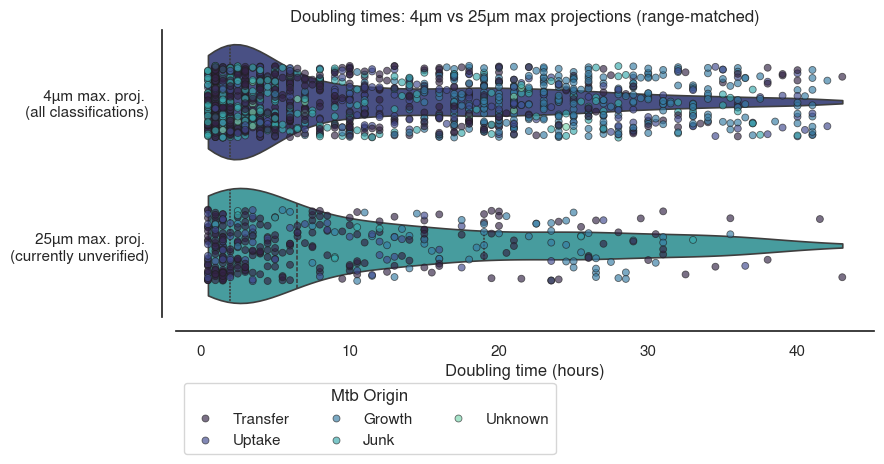

In [19]:
# Prepare datasets
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
# a["mtb_origin"] = "Unknown"

subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)

b = subset_og_df.copy().assign(Dataset="4µm max. proj.")
b = b[b["Doubling Times"] <= a["Doubling Times"].max()]

combo = pd.concat([a, b], ignore_index=True)
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)

# Plot — horizontal violins + jittered points
sns.set_theme(style="white")
plt.rcParams.update({"font.family": "Nimbus Sans"})

plt.figure(figsize=(9, 5))
ax = sns.violinplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    hue=None,
    cut=0,
    inner="quartile",
    scale="width",
    linewidth=1.2,
    palette="mako"
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    hue="mtb_origin",
    palette='mako',
    alpha=0.65,
    edgecolor="gray",
    linewidth=0.6,
    jitter=0.25,
    dodge=False
)

# Legend for mtb_origin only
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(
        handles=handles[-combo["mtb_origin"].nunique():],
        labels=labels[-combo["mtb_origin"].nunique():],
        title="Mtb Origin",
        bbox_to_anchor=(0.0, -0.2),
        loc="upper left",
        ncol=3,
        frameon=True,
    )

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel("")
ax.set_yticklabels([
    " 4µm max. proj. \n(all classifications)",
    "25µm max. proj. \n(currently unverified)"
])
ax.set_title("Doubling times: 4µm vs 25µm max projections (range-matched)")
plt.tight_layout()


In [ ]:
print()

# 3190 lamellapodia neighbour nearby

other cells to check:
1. 2978
2. 6014
3. 7380 - edge?
4. 4824 - edge
5. 1735, 7716 - growth???
6. 883 - needs to reset dt
7. 352 - need to reset dt
8. 402 - need to reset dt
9. 381 - need to reset dt?
10. 1861 - need to reset dt
11. 146 - need to recalculate dt
12. 132 - need to recalculate dt
13. 4221 - need to recalculate dt?
14. 1242 - need to recalculate dt?
15. 1128 - need to recalculate dt, or at least remove 0hr
16. 4141 - hm growth
17. 2167 - reinspect
18. 3956 - example of the necessity of 3D imaging
19. 2669 - vampiric cell
    

### Prelim results

/tmp/ipykernel_2149593/233332377.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_2149593/233332377.py:63: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_2149593/233332377.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


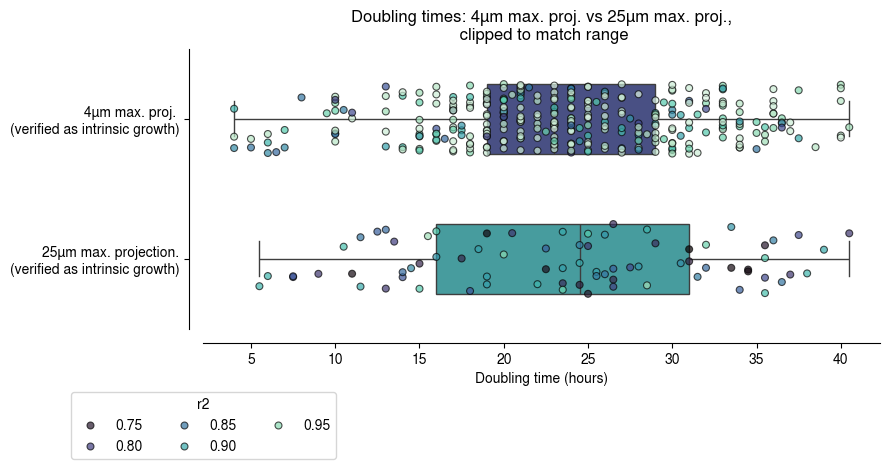

In [20]:
subset_df = (
    df.drop_duplicates(subset="ID")
      .dropna(subset=["Doubling Times"])
      .explode("Doubling Times")
)

subset_df = subset_df[
    # subset_df[id_key].isin(largest_IDs) &
    (subset_df["Doubling Times"] > 4) &
    (subset_df["r2"] >= 0.7)
].copy()

subset_df = subset_df[
    (subset_df["mtb_origin"] == 'Growth')
].copy()

subset_og_df = (
    og_df[
        (og_df["Compound"] == "CTRL")
        & (og_df["Concentration"] == "EC0")
        & (og_df["Strain"] == "WT")
        & (og_df["mtb_origin"] == "Growth")
    ]
    .drop_duplicates(subset="ID")
    .dropna(subset=["Doubling Times"])
    .explode("Doubling Times")
    .loc[lambda d: d["Doubling Times"] > 0]
)


# Label, stack, and plot both datasets as horizontal boxes stacked on Y
expanded_piyg = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

a = subset_df.copy().assign(Dataset="25µm max. proj.")
b = subset_og_df.copy().assign(Dataset="4µm max. proj.")

b = b[b['Doubling Times']<=a['Doubling Times'].max()]

combo = pd.concat([a, b], ignore_index=True)

combo = combo[combo['Doubling Times'] > 0].copy()

# Put the OG dataset on top
combo["Dataset"] = pd.Categorical(
    combo["Dataset"],
    categories=["4µm max. proj.", "25µm max. proj."],
    ordered=True
)


plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    whis=[0, 100],
    width=0.5,
    fliersize=0,
    palette="mako",
    # hue='r2'
)

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    palette="mako",
    alpha=0.7,
    edgecolor="gray",
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    hue='r2'
)

sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel('')
ax.set_yticklabels([
    " 4µm max. proj. \n(verified as intrinsic growth)",
    "25µm max. projection.\n(verified as intrinsic growth)"
])
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.,\n clipped to match range")
ax.legend(
    bbox_to_anchor=(0., -0.2),
    loc="upper center",
    ncol=3,   # spread across columns
    frameon=True, 
    title='r2'
)
plt.tight_layout()


### KDE plot

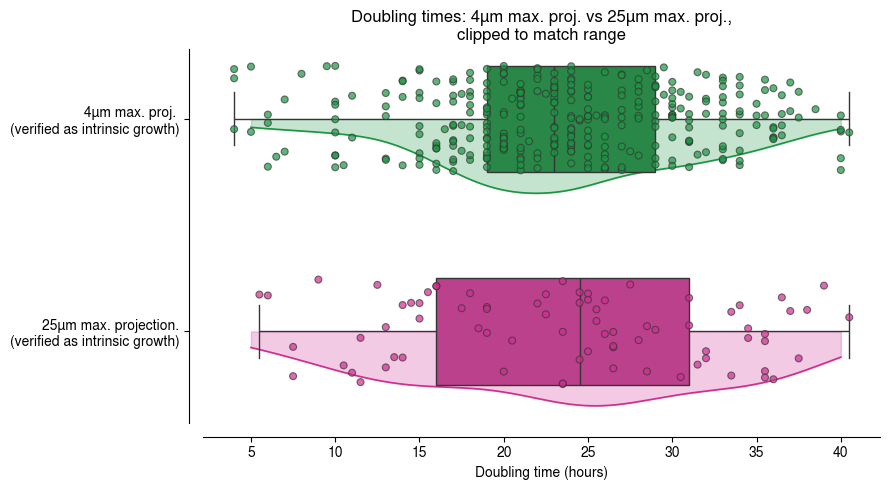

In [33]:

import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.ticker as mticker

# --- 0) Clean numeric + clip negatives again just in case ---
combo["Doubling Times"] = pd.to_numeric(combo["Doubling Times"], errors="coerce")
combo = combo.dropna(subset=["Doubling Times"])
combo = combo.loc[combo["Doubling Times"] > 0].copy()

# --- 1) Palette mapped to your two rows ---
cats = list(combo["Dataset"].cat.categories)  # ["4µm max. proj.", "25µm max. proj."]
pal = {
    "4µm max. proj.": '#1a9641',   # pick from your expanded_piyg
    "25µm max. proj.": '#d02c91',
}

plt.figure(figsize=(9, 5))
ax = sns.boxplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    hue="Dataset",           # <-- fixes FutureWarning
    dodge=False,
    whis=[0, 100],
    width=0.5,
    fliersize=0,
    palette=pal,
)
# remove auto legend added by hue
if ax.legend_ is not None:
    ax.legend_.remove()

sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    hue="Dataset",           # match colors to rows
    palette=pal,
    alpha=0.7,
    edgecolor="auto",        # <-- avoids grayscale deprecation
    linewidth=0.8,
    jitter=0.25,
    dodge=False,
    ax=ax,
)
# remove the second legend from stripplot
if ax.legend_ is not None:
    ax.legend_.remove()

# --- 2) Fixed y-ticks + custom labels (fixes ticklabels warning) ---
ax.yaxis.set_major_locator(mticker.FixedLocator(range(len(cats))))
ax.set_yticklabels([
    " 4µm max. proj. \n(verified as intrinsic growth)",
    "25µm max. projection.\n(verified as intrinsic growth)"
])

ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel('')
ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.,\nclipped to match range")
sns.despine(offset=10)

# If you still want an r2 legend, create it explicitly (optional)
# from matplotlib.lines import Line2D
# h = [Line2D([], [], marker='o', linestyle='', color='k', label='r2 (see colorbar/annotation)')]
# ax.legend(handles=h, bbox_to_anchor=(0., -0.2), loc="upper center", ncol=3, frameon=True, title='r2')

# --- 3) KDE ridge overlay per row ---
ypos = {name: i for i, name in enumerate(cats)}
x_lo = np.percentile(combo["Doubling Times"], 1)
x_hi = np.percentile(combo["Doubling Times"], 99)
x_grid = np.linspace(float(x_lo), float(x_hi), 400).astype(float)
ridge_scale = 0.35

for name in cats:
    x = (combo.loc[combo["Dataset"] == name, "Doubling Times"]
              .astype(float)
              .dropna()
              .values)
    if len(x) < 5:
        continue

    kde = gaussian_kde(x, bw_method="scott")
    dens = kde(x_grid)
    if not np.isfinite(dens).any():
        continue

    dens = dens / dens.max()  # normalize to [0, 1]
    y0 = ypos[name]
    y_curve = y0 + dens * ridge_scale

    ax.fill_between(x_grid, y0, y_curve,
                    color=pal[name], alpha=0.25, zorder=-5)
    ax.plot(x_grid, y_curve,
            color=pal[name], lw=1.2, zorder=-4)

plt.tight_layout()

### Violin plots

/tmp/ipykernel_2149593/2499051769.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


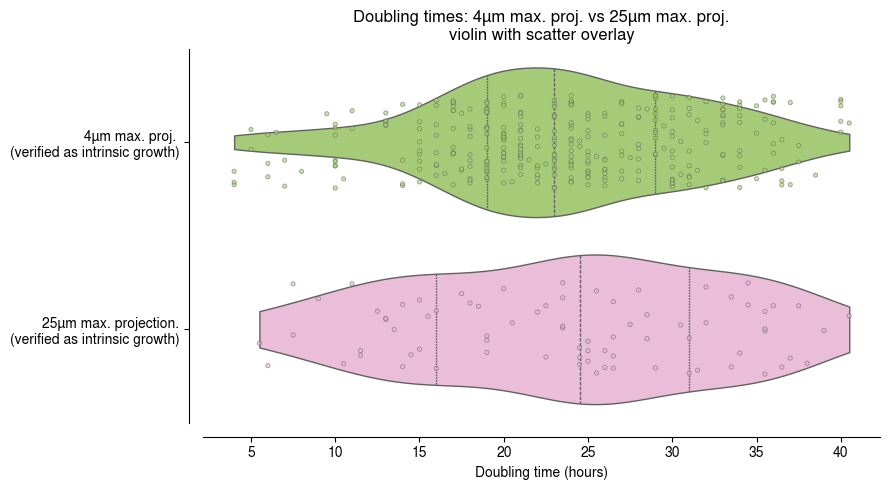

In [42]:
import matplotlib.ticker as mticker

# ensure numeric
combo["Doubling Times"] = pd.to_numeric(combo["Doubling Times"], errors="coerce")
combo = combo.dropna(subset=["Doubling Times"]).loc[lambda d: d["Doubling Times"] > 0].copy()

# consistent palette for the two rows
pal = {
    "4µm max. proj.": expanded_piyg[1],   # green
    "25µm max. proj.": expanded_piyg[-2], # magenta
}

plt.figure(figsize=(9, 5))
ax = sns.violinplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    hue="Dataset",          # avoids palette-without-hue deprecation
    dodge=False,
    palette=pal,
    inner='quart',             # no internal bars (clean shape) {“box”, “quart”, “point”, “stick”, None}
    cut=0,                  # don't extend beyond data range
    scale="width",          # comparable widths
    linewidth=1.0,
)
# remove auto legend from hue
if ax.legend_ is not None:
    ax.legend_.remove()

# overlay scatter (strip); for dense data, consider swarmplot (slower)
sns.stripplot(
    data=combo,
    x="Doubling Times",
    y="Dataset",
    hue="Dataset",
    palette=pal,
    dodge=False,
    jitter=0.25,
    alpha=0.6,
    edgecolor="auto",       # avoid grayscale deprecation
    linewidth=0.6,
    size=3,
    ax=ax,
)
# remove second legend
if ax.legend_ is not None:
    ax.legend_.remove()

# tidy axes + labels
sns.despine(offset=10)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel('')
# lock ticks first, then set labels (prevents warning)
ax.yaxis.set_major_locator(mticker.FixedLocator([0, 1]))
ax.set_yticklabels([
    " 4µm max. proj. \n(verified as intrinsic growth)",
    "25µm max. projection.\n(verified as intrinsic growth)"
])

# # optional: unify x-limits using shared quantiles to reduce tail dominance
# lo = combo["Doubling Times"].quantile(0.01)
# hi = combo["Doubling Times"].quantile(0.99)
# ax.set_xlim(lo, hi)

ax.set_title("Doubling times: 4µm max. proj. vs 25µm max. proj.\nviolin with scatter overlay")
plt.tight_layout()


In [38]:
print()

# Statistical test

In [22]:
import numpy as np
import pandas as pd
from scipy.stats import kruskal, mannwhitneyu

def to_clean_numeric(s: pd.Series) -> np.ndarray:
    v = pd.to_numeric(s, errors="coerce").to_numpy()
    v = v[np.isfinite(v)]
    return v

# Split and clean
g4_raw  = combo.loc[combo["Dataset"] == "4µm max. proj.",  "Doubling Times"]
g25_raw = combo.loc[combo["Dataset"] == "25µm max. proj.", "Doubling Times"]

g4  = to_clean_numeric(g4_raw)
g25 = to_clean_numeric(g25_raw)

print(f"n_4µm={g4.size}, n_25µm={g25.size}, medians=({np.median(g4):.2f}, {np.median(g25):.2f})")

# Kruskal–Wallis (works for k=2 but mainly for consistency with your other analyses)
H, p_kw = kruskal(g4, g25)
print(f"Kruskal–Wallis: H={H:.3f}, p={p_kw:.3e}")

# Mann–Whitney U (more standard for k=2) + rank-biserial effect size
U, p_u = mannwhitneyu(g4, g25, alternative="two-sided", method="auto")
rbc = 1 - (2 * U) / (g4.size * g25.size)
print(f"Mann–Whitney U: U={U:.1f}, p={p_u:.3e} | rank-biserial r={rbc:.3f}")

# Optional: bootstrap 95% CI for rank-biserial
def bootstrap_rbc(x, y, B=5000, seed=0):
    rng = np.random.default_rng(seed)
    n1, n2 = x.size, y.size
    vals = np.empty(B)
    for b in range(B):
        xs = x[rng.integers(0, n1, n1)]
        ys = y[rng.integers(0, n2, n2)]
        U_b, _ = mannwhitneyu(xs, ys, alternative="two-sided", method="auto")
        vals[b] = 1 - (2 * U_b) / (n1 * n2)
    return np.percentile(vals, [2.5, 97.5])

lo, hi = bootstrap_rbc(g4, g25)
print(f"rank-biserial 95% CI: [{lo:.3f}, {hi:.3f}]")


n_4µm=324, n_25µm=77, medians=(23.00, 24.50)
Kruskal–Wallis: H=0.093, p=7.601e-01
Mann–Whitney U: U=12195.0, p=7.605e-01 | rank-biserial r=0.022
rank-biserial 95% CI: [-0.134, 0.176]


In [18]:
len(subset_og_df['ID'].unique())

219

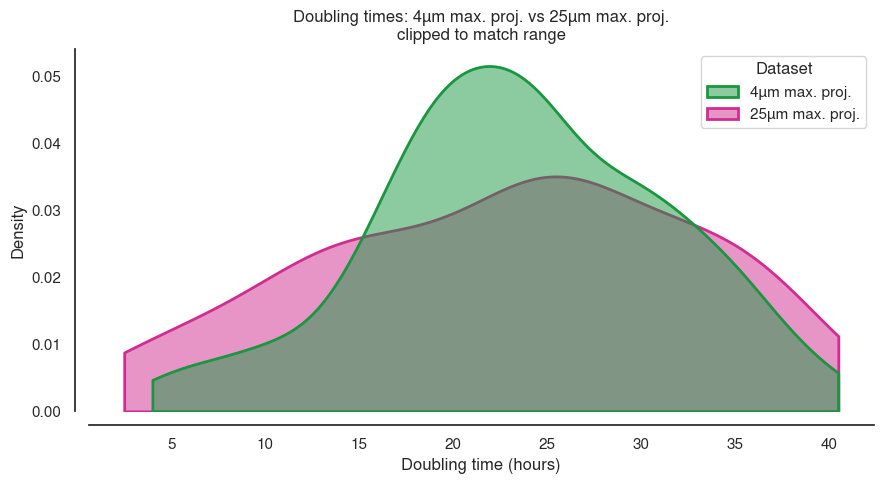

In [38]:
plt.figure(figsize=(9, 5))

# distinct, high-contrast colours
palette = {
    "4µm max. proj.": "#1a9641",   # teal-green
    "25µm max. proj.": "#d02c91",  # orange
}

xmax = a["Doubling Times"].max()

sns.kdeplot(
    data=combo,
    x="Doubling Times",
    hue="Dataset",
    fill=True,
    common_norm=False,
    alpha=0.5,         # adjust visibility
    linewidth=2,       # darker outlines
    clip=(0, xmax),
    cut=0,
    palette=palette
)

sns.despine(offset=10)
plt.xlabel("Doubling time (hours)")
plt.ylabel("Density")
plt.title("Doubling times: 4µm max. proj. vs 25µm max. proj.\nclipped to match range")
# plt.legend(
#     title="Dataset",
#     frameon=True,
#     loc="upper right",
#     facecolor="white"
# )
plt.tight_layout()


In [1]:
# 3190 lamellapodia neighbour nearby
notes = """
other cells to check:
1. 2978
2. 6014
3. 7380 - edge?
4. 4824 - edge
5. 1735, 7716 - growth???
6. 883 - needs to reset dt
7. 352 - need to reset dt
8. 402 - need to reset dt
9. 381 - need to reset dt?
10. 1861 - need to reset dt
11. 146 - need to recalculate dt
12. 132 - need to recalculate dt
13. 4221 - need to recalculate dt?
14. 1242 - need to recalculate dt?
15. 1128 - need to recalculate dt, or at least remove 0hr
16. 4141 - hm growth
17. 2167 - reinspect
18. 3956 - example of the necessity of 3D imaging
19. 2669 - vampiric cell
"""

In [9]:
import re

# 1) Grab the text after each enumerator like "1."
lines = re.findall(r'^\s*\d+\.\s*(.*)$', notes, flags=re.MULTILINE)

# 2) From those lines, extract all pure numeric IDs (handles "1735, 7716")
ids = [m for line in lines for m in re.findall(r'\b\d+\b', line)]

# (optional) de-dupe while keeping order, and cast to int
ids_unique = list(dict.fromkeys(map(int, ids)))

print(ids_unique)


[2978, 6014, 7380, 4824, 1735, 7716, 883, 352, 402, 381, 1861, 146, 132, 4221, 1242, 1128, 4141, 2167, 3956, 2669]


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/86 [00:00<?, ?it/s]

  0%|          | 0/86 [00:00<?, ?it/s]

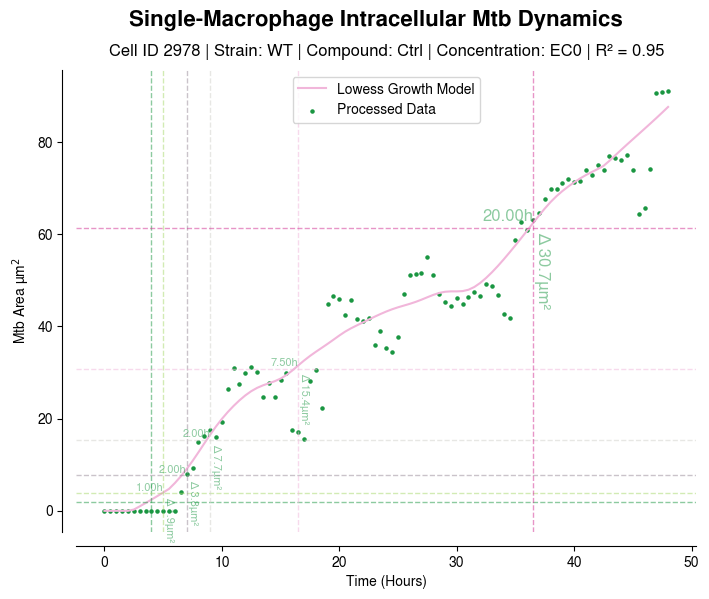

In [24]:
for ID in tqdm(ids_unique):
    val = df[df['ID'] == ID]['mtb_origin'].iloc[0]
    # if not pd.isna(val):
    #     print(f'Already classified ID: {ID} as {val}')
    #     continue
    # build slices around this ID
    slices, offsets = compute_roi_slices_tczyx(
        df, ID, images,
        pad_xy=400,
        keep_full_z=True   # <- keep all 25 Z planes
        # or keep_full_z=False, z_fixed=12, pad_z=2 to keep a small Z slab
    )
    
    # dask-lazy crops
    img_crop, msk_crop = crop_images_masks_tczyx(images, masks, slices)
    img_crop = timed_compute(img_crop)
    msk_crop = timed_compute(msk_crop)
    viewer = napari.Viewer(title=f'inspecting dts for ID {ID}')
    viewer.add_image(img_crop, channel_axis=1, scale=scale)
    viewer.add_labels(msk_crop, visible=False, scale=scale)
    napari_tracks = adjust_tracks_fixed_z(tracks, ID, slices)[['ID', 't', 'z', 'y', 'x']].values
    viewer.add_tracks(napari_tracks, scale=scale)
    # viewer.bind_key('t', mark_transfer)
    # viewer.bind_key('u', mark_uptake)
    # viewer.bind_key('j', mark_junk)
    # viewer.bind_key('s', save_df)
    # viewer.bind_key('g', mark_growth)
    plot(ID, df)
    break
    # viewer.show(block=True)
    # plt.close()

In [52]:
track_scale = (1,0.149,0.149)

In [53]:
napari_tracks

array([[2.978e+03, 0.000e+00, 1.200e+01, 4.280e+02, 4.000e+02],
       [2.978e+03, 1.000e+00, 1.200e+01, 4.280e+02, 4.090e+02],
       [2.978e+03, 2.000e+00, 1.200e+01, 4.480e+02, 4.240e+02],
       [2.978e+03, 3.000e+00, 1.200e+01, 4.530e+02, 4.300e+02],
       [2.978e+03, 4.000e+00, 1.200e+01, 4.600e+02, 4.380e+02],
       [2.978e+03, 5.000e+00, 1.200e+01, 4.520e+02, 4.480e+02],
       [2.978e+03, 6.000e+00, 1.200e+01, 4.820e+02, 4.660e+02],
       [2.978e+03, 7.000e+00, 1.200e+01, 4.870e+02, 4.780e+02],
       [2.978e+03, 8.000e+00, 1.200e+01, 4.880e+02, 4.800e+02],
       [2.978e+03, 9.000e+00, 1.200e+01, 4.690e+02, 4.970e+02],
       [2.978e+03, 1.000e+01, 1.200e+01, 4.510e+02, 4.970e+02],
       [2.978e+03, 1.100e+01, 1.200e+01, 4.370e+02, 4.880e+02],
       [2.978e+03, 1.200e+01, 1.200e+01, 4.420e+02, 4.920e+02],
       [2.978e+03, 1.300e+01, 1.200e+01, 4.410e+02, 4.910e+02],
       [2.978e+03, 1.400e+01, 1.200e+01, 4.370e+02, 4.910e+02],
       [2.978e+03, 1.500e+01, 1.200e+01,

<Tracks layer 'napari_tracks [1]' at 0x7e2d3add9f50>